In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt

In [ ]:
df = pd.read_csv("AirPassengers.csv")
print(df.head())
print(df.tail())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121
       Month  #Passengers
139  1960-08          606
140  1960-09          508
141  1960-10          461
142  1960-11          390
143  1960-12          432


In [ ]:
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
print(df.head())

       Month  #Passengers
0 1949-01-01          112
1 1949-02-01          118
2 1949-03-01          132
3 1949-04-01          129
4 1949-05-01          121


In [ ]:
# Rename the column first
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

In [ ]:
df.index = df['Month']
del df['Month']
print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


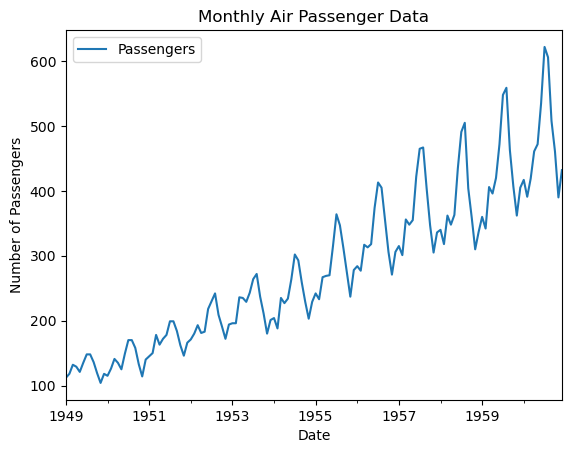

In [ ]:
df.plot()
plt.title("Monthly Air Passenger Data")
plt.ylabel("Number of Passengers")
plt.xlabel("Date")
plt.show()

In [ ]:
df['Date'] = df.index

# Train: before Aug 1960
train = df[df['Date'] < pd.to_datetime("1960-08", format='%Y-%m')]
train['train'] = train['Passengers']
del train['Date']
del train['Passengers']
print(train.head())

# Test: Aug 1960 onwards
test = df[df['Date'] >= pd.to_datetime("1960-08", format='%Y-%m')]
test['test'] = test['Passengers']
del test['Date']
del test['Passengers']
print(test)
print(test.shape)

            train
Month            
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
            test
Month           
1960-08-01   606
1960-09-01   508
1960-10-01   461
1960-11-01   390
1960-12-01   432
(5, 1)


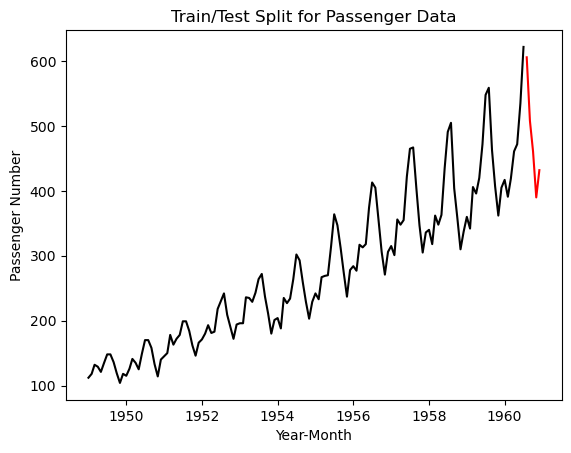

In [ ]:
plt.plot(train, color="black")
plt.plot(test, color="red")
plt.title("Train/Test Split for Passenger Data")
plt.ylabel("Passenger Number")
plt.xlabel("Year-Month")
plt.show()

In [ ]:
!pip install pmdarima
from pmdarima.arima import auto_arima

model = auto_arima(train)
forecast = pd.DataFrame(model.predict(n_periods=5), index=test.index)
forecast.columns = ['test']
print(forecast)

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 613.3/613.3 kB 6.4 MB/s eta 0:00:00
                  test
Month                 
1960-08-01  609.537719
1960-09-01  569.572563
1960-10-01  524.516337
1960-11-01  483.040358
1960-12-01  480.301281


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['test'], forecast['test'])
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 53.99365169667341


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test['test'], forecast['test'])
print(f"MAPE: {mape * 100:.2f}%")


MAPE: 12.30%
